In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from konlpy.tag import Okt
import re

from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score

- 데이터 경로

In [2]:
TRAIN_DATA_PATH = "./data/train/"
TRAIN_THR_DATA_PATH = "./data/train/threaten/"
TRAIN_GEN_DATA_PATH = "./data/train/general/"
TEST_DATA_PATH = "./data/test/"

# 1. 학습 데이터 합치기

중간에 합칠 대상만 넣고 빼고 하면서 데이터를 만들면 될 것 같습니다.  
다만 합친 최종 데이터가 기존 최종 데이터에 덮어쓰기 되지 않도록 주의를 기울어야 합니다.  
초기 성능 측정 시 모든 데이터를 다 사용합니다.  

- 괴롭힘 대화  
    - train_aug_kek_jy.csv: 주열님이 역번역 하신 괴롭힘 문장 2종 (k->e->k)  
    - train_aug_kek_sy.csv: 수연님이 역번역 하신 괴롭힘 문장 2종 (k->e->k)      
    - train_aug_kjk_mk.csv: 제가 역번역 하신 괴롭힘 문장 4종 (k->j->k)  
    - train_origin.csv: 최초 제공 데이터(train.csv) (괴롭힘 대화 4종)  
- 일반 대화  
    - train_aug_gen_llm_jy.csv: 주열님이 클로드로 생성한 일반 대화를 역번역 해서 aug한 것 (560개)
    - train_aug_gen_llm_mk.csv: 제가 제미나이로 생성한 일반 대화(v2)를 역번역(k->j->k) 해서 aug한 것 (1000개)
    - train_gen_llm_jy.csv: 주열님이 클로드로 생성한 일반 대화 (560개)
    - train_gen_llm_mk.csv: 제가 제미나이로 생성한 일반 대화(v2) (1000개)
    - train_gen_llm_sy.csv: 수연님이 Ollama로 생성한 일반 대화 (1000개)

## 1.1. 괴롭힘 대화 합치기

### 1.1.1. 원래 대화 + 역번역 대화(kek) + 역번역 대화(kjk)

In [3]:
# 1. 데이터 불러오기
train_aug_kek_jy_df = pd.read_csv(TRAIN_THR_DATA_PATH + 'train_aug_kek_jy.csv')
train_aug_kek_sy_df = pd.read_csv(TRAIN_THR_DATA_PATH + 'train_aug_kek_sy.csv')
train_aug_kjk_mk_df = pd.read_csv(TRAIN_THR_DATA_PATH + 'train_aug_kjk_mk.csv')
train_origin_df = pd.read_csv(TRAIN_THR_DATA_PATH + 'train_origin.csv')

# 소스 추적을 위해 어디서 왔는지 기록하는 컬럼 추가
train_aug_kek_jy_df['source'] = "train_aug_kek_jy"
train_aug_kek_sy_df['source'] = "train_aug_kek_sy"
train_aug_kjk_mk_df['source'] = "train_aug_kjk_mk"
train_origin_df['source'] = "train_origin"

print(len(train_aug_kek_jy_df))
print(len(train_aug_kek_sy_df))
print(len(train_aug_kjk_mk_df))
print(len(train_origin_df))

1957
1990
3950
3950


In [4]:
# 데이터 통합 (Vertical Concatenation)
combined_thr_df = pd.concat([train_aug_kek_jy_df, train_aug_kek_sy_df, train_aug_kjk_mk_df, train_origin_df], axis=0, ignore_index=True)

# idx 컬럼 재설정
combined_thr_df['idx'] = combined_thr_df.index

# 컬럼 순서 정리 (보기 좋게 배치)
combined_thr_df = combined_thr_df[['idx', 'class', 'conversation', 'source']]

In [5]:
print(len(combined_thr_df))
combined_thr_df.head()
# combined_thr_df.tail()

11847


,idx,class,conversation,source
0,0,갈취 대화,"안녕하세요\n응??\n너, 내 말은 너야.이리 와봐\n무슨 일이 있었나요?\n옷이 ...",train_aug_kek_jy
1,1,갈취 대화,"야, 정말 너무 더워? 우리 회사에서 이 자외선 차단제를 판매해요.손등에 한번 발라...",train_aug_kek_jy
2,2,갈취 대화,귀하의 세금계산서에 기재된 번호가 귀하께서 보내주신 이메일과 다르다고 들었습니다.\...,train_aug_kek_jy
3,3,갈취 대화,"응, 무엇을 드릴까요?\n원 말보르 레드.\n응.여기요!\n여기 사장님 없나요?\n...",train_aug_kek_jy
4,4,갈취 대화,"형제!형제!돈 좀 있어요?\n나, 나.?\n여기 너 말고 또 누가 있어? 형, 얼마...",train_aug_kek_jy


In [6]:
# 통합된 데이터 저장 
combined_thr_df.to_csv(TRAIN_THR_DATA_PATH + 'combined_thr_train.csv', index=False, encoding='utf-8-sig')

## 1.2. 일반 대화 합치기

### 1.2.1. 일반 생성 3개 + 역번역 2개

In [7]:
# 1. 데이터 불러오기
train_aug_gen_llm_jy_df = pd.read_csv(TRAIN_GEN_DATA_PATH + 'train_aug_gen_llm_jy.csv')
train_aug_gen_llm_mk_df = pd.read_csv(TRAIN_GEN_DATA_PATH + 'train_aug_gen_llm_mk.csv')
train_gen_llm_jy_df = pd.read_csv(TRAIN_GEN_DATA_PATH + 'train_gen_llm_jy.csv')
train_gen_llm_mk_df = pd.read_csv(TRAIN_GEN_DATA_PATH + 'train_gen_llm_mk.csv')
train_gen_llm_sy_df = pd.read_csv(TRAIN_GEN_DATA_PATH + 'train_gen_llm_sy.csv')

# 일반 대화 class 추가
train_gen_llm_sy_df['class'] = "일반 대화"

# 소스 추적을 위해 어디서 왔는지 기록하는 컬럼 추가
train_aug_gen_llm_jy_df["source"] = "train_aug_gen_llm_jy"
train_aug_gen_llm_mk_df["source"] = "train_aug_gen_llm_mk"
train_gen_llm_jy_df['source'] = "train_gen_llm_jy"
train_gen_llm_mk_df['source'] = "train_gen_llm_mk"
train_gen_llm_sy_df['source'] = "train_gen_llm_sy"

print(len(train_aug_gen_llm_jy_df))
print(len(train_aug_gen_llm_mk_df))
print(len(train_gen_llm_jy_df))
print(len(train_gen_llm_mk_df))
print(len(train_gen_llm_sy_df))

560
1000
560
1000
1000


In [8]:
# 데이터 통합 (Vertical Concatenation)
combined_gen_df = pd.concat([train_aug_gen_llm_jy_df, train_aug_gen_llm_mk_df, train_gen_llm_jy_df, train_gen_llm_mk_df, train_gen_llm_sy_df], axis=0, ignore_index=True)

# idx 컬럼 재설정
combined_gen_df['idx'] = combined_gen_df.index

# 컬럼 순서 정리 (보기 좋게 배치)
combined_gen_df = combined_gen_df[['idx', 'class', 'conversation', 'source']]

In [9]:
print(len(combined_gen_df))
# combined_gen_df.head()
combined_gen_df.tail()

4120


,idx,class,conversation,source
4115,4115,일반 대화,이제 휴일을 계획하고 있는 거야?\n내일부터는 바다로 가자고 생각해.\n무엇으로 갈...,train_gen_llm_sy
4116,4116,일반 대화,가족이 모인 날엔 항상 맛있는 음식을 해먹는 거 같아요.\n이제 저희집에 가서 점심...,train_gen_llm_sy
4117,4117,일반 대화,이제 토익시험 보러 가야 해.\n내일부터는 일찍 일어날 거야.\n왜 그래 저녁에 늦...,train_gen_llm_sy
4118,4118,일반 대화,"안녕하세요! 좋은 날이네요.\n너무 뜨겁다 싶다!\n아침에 가자고 했다만, 시간이 ...",train_gen_llm_sy
4119,4119,일반 대화,이제 내일도 일찍에 출근해야 해요.\n점심에 뭐 먹을까 싶어요.\n어떤 음식을 만들...,train_gen_llm_sy


In [10]:
combined_gen_df.to_csv(TRAIN_GEN_DATA_PATH + 'combined_gen_train.csv', index=False, encoding='utf-8-sig')

## 1.3. 학습 데이터 최종 결합

### 1.3.1. 괴롭힘 대화 + 일반 대화 

In [11]:
# 1. 데이터 불러오기
thr_df = pd.read_csv(TRAIN_THR_DATA_PATH + 'combined_thr_train.csv') # 괴롭힘 대화
# gen_df = pd.read_csv(TRAIN_GEN_DATA_PATH + 'combined_gen_train.csv') # 일반 대화

print(len(thr_df))
print(len(gen_df))

11847


NameError: name 'gen_df' is not defined

In [12]:
# 데이터 통합 (Vertical Concatenation)
combined_train_df = pd.concat([thr_df, gen_df], axis=0, ignore_index=True)

# idx 컬럼 재설정
combined_train_df['idx'] = combined_train_df.index

# 컬럼 순서 정리 (보기 좋게 배치)
combined_train_df = combined_train_df[['idx', 'class', 'conversation', 'source']]

NameError: name 'gen_df' is not defined

In [ ]:
# combined_train_df = thr_df # 괴롭힘 문장만 사용

In [31]:
print(len(combined_train_df))
combined_train_df.head()
# combined_train_df.tail()

15967


,idx,class,conversation,source
0,0,갈취 대화,"안녕하세요\n응??\n너, 내 말은 너야.이리 와봐\n무슨 일이 있었나요?\n옷이 ...",train_aug_kek_jy
1,1,갈취 대화,"야, 정말 너무 더워? 우리 회사에서 이 자외선 차단제를 판매해요.손등에 한번 발라...",train_aug_kek_jy
2,2,갈취 대화,귀하의 세금계산서에 기재된 번호가 귀하께서 보내주신 이메일과 다르다고 들었습니다.\...,train_aug_kek_jy
3,3,갈취 대화,"응, 무엇을 드릴까요?\n원 말보르 레드.\n응.여기요!\n여기 사장님 없나요?\n...",train_aug_kek_jy
4,4,갈취 대화,"형제!형제!돈 좀 있어요?\n나, 나.?\n여기 너 말고 또 누가 있어? 형, 얼마...",train_aug_kek_jy


In [32]:
combined_train_df.to_csv(TRAIN_DATA_PATH + 'combined_train.csv', index=False, encoding='utf-8-sig')

# 2. 데이터 전처리

In [3]:
# 합친 데이터 불러오기
train_df = pd.read_csv(TRAIN_DATA_PATH + 'combined_train.csv')
print(len(train_df))

15967


## 2.1. 중복(대화, 라벨 모두 중복) 데이터 제거

In [4]:
# 1. 대화 내용(conversation)은 같은데 클래스(class)가 다른 경우 확인 (심각한 문제)
# 모델에게 혼란을 주는 '레이블 노이즈'입니다.
conflict_duplicates = train_df[train_df.duplicated(subset=['conversation'], keep=False)]
conflict_diff_class = conflict_duplicates.groupby('conversation').filter(lambda x: x['class'].nunique() > 1)

print(f"내용은 같으나 클래스가 다른 데이터 건수: {len(conflict_diff_class)}건")

if not conflict_diff_class.empty:
    print("\n--- 클래스 충돌 샘플 ---")
    print(conflict_diff_class[['class', 'conversation']].sort_values(by='conversation').head(4))

내용은 같으나 클래스가 다른 데이터 건수: 0건


In [5]:
# 1. 완전히 동일한 행(class와 conversation 모두 동일) 확인
exact_duplicates = train_df[train_df.duplicated(subset=['class', 'conversation'], keep=False)]
print(f"완전 중복 데이터 건수: {len(exact_duplicates)}건")
exact_duplicates.sort_values(by='conversation').head(10)

완전 중복 데이터 건수: 626건


,idx,class,conversation,source
10522,10522,갈취 대화,100만원만 어떻게 해주라.\n저 번에 빌린 돈도 안 갚았잖아. 그 동안 빌린 돈이...,train_origin
10968,10968,갈취 대화,100만원만 어떻게 해주라.\n저 번에 빌린 돈도 안 갚았잖아. 그 동안 빌린 돈이...,train_origin
7286,7286,갈취 대화,18살이 될 때까지요\n이건 최고야. 이건 24.\n부러워요. 내가 할 수 있는 일...,train_aug_kjk_mk
4644,4644,갈취 대화,18살이 될 때까지요\n이건 최고야. 이건 24.\n부러워요. 내가 할 수 있는 일...,train_aug_kjk_mk
7018,7018,갈취 대화,1천만엔으로 뭘 할까요?\n빚은 갚지 않았어 얼마나 빌렸는지 알아?\n내가 막지 않...,train_aug_kjk_mk
6572,6572,갈취 대화,1천만엔으로 뭘 할까요?\n빚은 갚지 않았어 얼마나 빌렸는지 알아?\n내가 막지 않...,train_aug_kjk_mk
4847,4847,협박 대화,5년 전 날 다친 것에 대해 사과해\n내가 너한테 뭘 한 거야?\n범인은 기억이 안...,train_aug_kjk_mk
5373,5373,협박 대화,5년 전 날 다친 것에 대해 사과해\n내가 너한테 뭘 한 거야?\n범인은 기억이 안...,train_aug_kjk_mk
2145,2145,협박 대화,5년 전 당신이 나에게 상처를 주었던 모든 말에 대해 사과드립니다.\n내가 너한테 ...,train_aug_kek_sy
2276,2276,협박 대화,5년 전 당신이 나에게 상처를 주었던 모든 말에 대해 사과드립니다.\n내가 너한테 ...,train_aug_kek_sy


중복 데이터 제거 후 확인

In [6]:
train_df_cleaned = train_df[['class', 'conversation']].drop_duplicates()
print(len(train_df_cleaned))
after_counts = train_df_cleaned['class'].value_counts()
print(after_counts, "\n")

15654
class
일반 대화          4120
기타 괴롭힘 대화      3030
갈취 대화          2918
직장 내 괴롭힘 대화    2907
협박 대화          2679
Name: count, dtype: int64 



In [7]:
# 5. 차이 계산
before_counts = train_df['class'].value_counts()
print(before_counts, "\n")

summary = pd.DataFrame({
    '원본 건수': before_counts,
    '중복 제거 후': after_counts,
    '제거된 건수': before_counts - after_counts
})

# 6. 보기 좋게 정렬 및 출력
summary = summary.sort_values(by='제거된 건수', ascending=False)
print("--- 클래스별 중복 데이터 제거 현황 ---", "\n")
print(summary)

print(f"\n전체 원본 데이터: {len(train_df)}건")
print(f"최종 남은 데이터: {len(train_df_cleaned)}건")
print(f"총 제거된 중복: {len(train_df) - len(train_df_cleaned)}건")

class
일반 대화          4120
기타 괴롭힘 대화      3282
갈취 대화          2943
직장 내 괴롭힘 대화    2934
협박 대화          2688
Name: count, dtype: int64 

--- 클래스별 중복 데이터 제거 현황 --- 

             원본 건수  중복 제거 후  제거된 건수
class                              
기타 괴롭힘 대화     3282     3030     252
직장 내 괴롭힘 대화   2934     2907      27
갈취 대화         2943     2918      25
협박 대화         2688     2679       9
일반 대화         4120     4120       0

전체 원본 데이터: 15967건
최종 남은 데이터: 15654건
총 제거된 중복: 313건


In [8]:
# def show_stats(df):
#     stat_df = pd.DataFrame()

#     stat_df['total_char'] = df['conversation'].apply(len) # 대화 전체 길이
#     stat_df['sent_count'] = df['conversation'].apply(lambda x: len([s for s in x.split('\n') if s.strip()])) # 대화 내 문장 개수
#     stat_df['total_word'] = df['conversation'].apply(lambda x: len(x.split())) # 대화 내 단어(어절) 개수

#     # 2. 대화 1개당 '문장들의 평균 길이' 계산
#     stat_df['avg_sent_len_in_conv'] = stat_df['total_char'] / stat_df['sent_count']

#     # 3. LLM에게 줄 가이드 수치 뽑기 (중앙값 기준)
#     print(f"대화 1개당 전체 글자수 중앙값: {stat_df['total_char'].median()}자")
#     print(f"대화 1개당 전체 글자수 평균값: {stat_df['total_char'].mean()}자")
#     print(f"대화 1개당 문장 개수 중앙값: {stat_df['sent_count'].median()}개")
#     print(f"대화 1개당 문장 개수 평균값: {stat_df['sent_count'].mean()}개")
#     print(f"대화 1개당 전체 단어수 중앙값: {stat_df['total_word'].median()}개")
#     print(f"대화 1개당 전체 단어수 평균값: {stat_df['total_word'].mean()}개")
#     print(f"대화 내 개별 문장 평균 길이 중앙값: {stat_df['avg_sent_len_in_conv'].median():.1f}자")
#     print(f"대화 내 개별 문장 평균 길이 평균값: {stat_df['avg_sent_len_in_conv'].mean():.1f}자")

#     return stat_df

In [9]:
# stat_df = show_stats(train_df_cleaned)

In [10]:
# # 2. 히스토그램 그리기 (2x2 레이아웃)
# def get_histogram(df):
#     fig, axes = plt.subplots(2, 2, figsize=(15, 12))
#     fig.suptitle('Distribution of Conversation Metrics with Mean & Median', fontsize=16)

#     # 분석할 컬럼들과 설정들
#     metrics = ['total_char', 'sent_count', 'total_word', 'avg_sent_len_in_conv']
#     titles = ['Total Character Count', 'Sentence Count', 'Total Word Count', 'Average Sentence Length per Conv']
#     colors = ['skyblue', 'salmon', 'lightgreen', 'orchid']
#     axes_flat = axes.flatten()

#     for i in range(4):
#         ax = axes_flat[i]
#         col = metrics[i]
        
#         # 1. 히스토그램 그리기 (sent_count만 정수 처리)
#         if col == 'sent_count':
#             # 막대가 정수 위에 오도록 설정
#             bins = np.arange(df[col].min(), df[col].max() + 2) - 0.5
#             sns.histplot(df[col], bins=bins, kde=True, ax=ax, color=colors[i])
#             # X축 눈금을 정수로 강제 설정
#             ax.set_xticks(np.arange(df[col].min(), df[col].max() + 1))
#         else:
#             # 나머지는 일반적인 히스토그램
#             sns.histplot(df[col], bins=30, kde=True, ax=ax, color=colors[i])
        
#         # 2. 통계치 계산
#         mean_val = df[col].mean()
#         median_val = df[col].median()
        
#         # 3. 평균/중앙값 선 긋기
#         ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
#         ax.axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
        
#         # 4. 개별 서브플롯 설정
#         ax.set_title(titles[i])
#         ax.legend() # label로 설정한 Mean과 Median 정보를 박스로 표시

#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.show()

In [11]:
# get_histogram(stat_df)

In [12]:
# 3. 주요 키워드 추출 (특징 단어 분석)
okt = Okt()
# mecab = Mecab()
def get_keywords(text, tokenizer):
    # 명사(Noun)와 동사(Verb) 위주로 추출하여 특징 파악    
    pos = tokenizer.pos(text, stem=True)
    return [word for word, tag in pos if tag in ['Noun', 'Verb'] and len(word) > 1]

In [13]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # 클래스별로 대화를 하나로 뭉침 (총 4개 또는 5개의 거대 문장 생성)
# class_docs = []
# classes = train_df_cleaned['class'].unique()

# for cls in classes:
#     class_docs.append(" ".join(train_df_cleaned[train_df_cleaned['class'] == cls]['conversation']))

# # Okt 토크나이저를 연결한 TF-IDF
# tfidf = TfidfVectorizer(tokenizer=lambda x: get_keywords(x, okt))
# tfidf_matrix = tfidf.fit_transform(class_docs)

# # 결과 확인
# words = tfidf.get_feature_names_out()
# for i, cls in enumerate(classes):
#     print(f"\n[{cls}] 핵심 키워드 (TF-IDF 기준):")
#     # i번째 클래스의 TF-IDF 점수가 높은 상위 10개 추출
#     row = tfidf_matrix.getrow(i).toarray()[0]
#     top_indices = row.argsort()[-20:][::-1]
#     print([words[idx] for idx in top_indices])

## 2.2. Data split 및 전처리

### 2.2.1. Data split

In [14]:
# 사용되는 input: 위에서 중복 대화 제거한 train_df_cleaned

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [16]:
# 레이블 인코딩 (문자열 -> 숫자)
# 모델 학습을 위해 '협박 대화' 등을 0, 1, 2... 숫자로 바꿉니다.
label_dict = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일반 대화': 4
}

# label_dict = {
#     '협박 대화': 0,
#     '갈취 대화': 1,
#     '직장 내 괴롭힘 대화': 2,
#     '기타 괴롭힘 대화': 3,
# }


In [17]:
train_df_cleaned['label'] = train_df_cleaned['class'].map(label_dict)
train_df_cleaned.head()
# train_df_cleaned.tail()

,class,conversation,label
0,갈취 대화,"안녕하세요\n응??\n너, 내 말은 너야.이리 와봐\n무슨 일이 있었나요?\n옷이 ...",1
1,갈취 대화,"야, 정말 너무 더워? 우리 회사에서 이 자외선 차단제를 판매해요.손등에 한번 발라...",1
2,갈취 대화,귀하의 세금계산서에 기재된 번호가 귀하께서 보내주신 이메일과 다르다고 들었습니다.\...,1
3,갈취 대화,"응, 무엇을 드릴까요?\n원 말보르 레드.\n응.여기요!\n여기 사장님 없나요?\n...",1
4,갈취 대화,"형제!형제!돈 좀 있어요?\n나, 나.?\n여기 너 말고 또 누가 있어? 형, 얼마...",1


In [18]:
# # Stratified Split (클래스 비율을 유지하며 분할)
# # test_size는 보통 0.1~0.2 정도로 잡습니다.
# train_df, val_df = train_test_split(
#     train_df_cleaned, 
#     test_size=0.1, 
#     stratify=train_df_cleaned['class'], # 클래스 비율 유지
#     random_state=42
# )

In [19]:
# balanced validation set 적용 시

# 1. 각 클래스별로 300개씩 뽑아서 Validation Set 구축
val_size_per_class = 300 

val_df = train_df_cleaned.groupby('label').sample(n=val_size_per_class, random_state=42)

# 2. 전체 데이터에서 Validation에 포함된 데이터를 제외하고 학습 데이터로 사용
train_df = train_df_cleaned.drop(val_df.index).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"학습 데이터 크기: {len(train_df)}")
print(f"검증 데이터 크기: {len(val_df)} (모든 클래스 {val_size_per_class}개씩 동일)")

학습 데이터 크기: 14154
검증 데이터 크기: 1500 (모든 클래스 300개씩 동일)


In [20]:
train_counts = train_df['class'].value_counts()
print(train_counts, "\n")

val_counts = val_df['class'].value_counts()
print(val_counts, "\n")

class
일반 대화          3820
기타 괴롭힘 대화      2730
갈취 대화          2618
직장 내 괴롭힘 대화    2607
협박 대화          2379
Name: count, dtype: int64 

class
협박 대화          300
갈취 대화          300
직장 내 괴롭힘 대화    300
기타 괴롭힘 대화      300
일반 대화          300
Name: count, dtype: int64 



### 2.2.2. 전처리

In [21]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. 양끝 공백 제거
    text = text.strip()
    
    # 2. 연속된 공백을 하나로 통일 (스페이스, 탭 등)
    text = re.sub(r'\s+', ' ', text)
    
    # 3. 연속된 개행문자(\n) 정제
    # 문장 구분을 위해 \n은 살려두되, 2개 이상 연속되면 1개로 줄임
    text = re.sub(r'\n+', '\n', text)
    
    # 4. 반복되는 자음/모음 정제 (예: ㅋㅋㅋㅋ -> ㅋㅋ)
    # 'soynlp' 라이브러리가 없다면 간단하게 정규식으로 처리
    text = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', text)
    
    # 5. 반복되는 특수문자 정제 (예: .... -> ..)
    text = re.sub(r'([\.\!\?])\1+', r'\1\1', text)

    return text

In [22]:
# 적용 후 중복 데이터가 발생하는지 확인 (중요!)
print(len(train_df))
print(len(val_df))
train_df = train_df.drop_duplicates(subset=['conversation']).reset_index(drop=True)
val_df = val_df.drop_duplicates(subset=['conversation']).reset_index(drop=True)
print(len(train_df))
print(len(val_df))

14154
1500
14154
1500


In [23]:
train_df.head()

,class,conversation,label
0,갈취 대화,"안녕하세요\n응??\n너, 내 말은 너야.이리 와봐\n무슨 일이 있었나요?\n옷이 ...",1
1,갈취 대화,"야, 정말 너무 더워? 우리 회사에서 이 자외선 차단제를 판매해요.손등에 한번 발라...",1
2,갈취 대화,귀하의 세금계산서에 기재된 번호가 귀하께서 보내주신 이메일과 다르다고 들었습니다.\...,1
3,갈취 대화,"응, 무엇을 드릴까요?\n원 말보르 레드.\n응.여기요!\n여기 사장님 없나요?\n...",1
4,갈취 대화,"형제!형제!돈 좀 있어요?\n나, 나.?\n여기 너 말고 또 누가 있어? 형, 얼마...",1


## 2.3. 토큰화 및 인덱싱

In [24]:
# train_df[train_df['conversation'].str.len() > 5]
# val_df[val_df['conversation'].str.len() > 5]

In [25]:
# 샘플 출력해서 눈으로 확인 (전처리가 의도대로 됐는지)
print("--- 전처리 결과 샘플 ---")
print(train_df.loc[0, 'conversation'])
print(f"\n라벨: {train_df.loc[0, 'class']} (숫자: {train_df.loc[0, 'label']})")

--- 전처리 결과 샘플 ---
안녕하세요
응??
너, 내 말은 너야.이리 와봐
무슨 일이 있었나요?
옷이 잘 어울리나요?
그 사람 돈이 좀 있을 텐데
아니요, 돈이 없어요.
찾아보고 나오면 죽는다.
오늘 PC방 통화?
전화하세요.마지막 기회예요.당신이 가진 모든 것을 나에게 주세요.
정말 하나도 없네

라벨: 갈취 대화 (숫자: 1)


### 2.3.1. 토크나이저 설정

In [26]:
from transformers import AutoTokenizer

모델
- roberta-base  
한국어 문맥 파악 능력 좋음  
복잡한 추론 능력은 Large보다 낮지만 속도가 빠름  
- KcELECTRA-base  
실제 test.csv에는 LLM이 만든 정제된 문장보다 훨씬 더 구어체스러운 노이즈가 많을 것입니다. KcELECTRA는 klue 모델이 놓치는 '현실 말투'를 보완해 줍니다.  
특히 "일반 대화"와 "괴롭힘"을 구분할 때, 일상적인 말투의 미묘한 차이를 가장 잘 캐치할 모델입니다.  

위에서 데이터를 통일해서 사용했다면, 다른 조합 사용해서 실험하셔도 좋을 것 같습니다. 

- 실험 예  
기본 세팅은 roberta-base, KcELECTRA-base로 놓고 데이터를 일부 빼면서 실험  
데이터를 전체 다 사용하고 모델을 roberta-large를 써본다거나 변경해서 사용

In [27]:
# roberta-base 불러오기 (한국어 문맥 파악 잘 하면서 빠름)
roberta_nm = "klue/roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_nm)


In [28]:
# KcELECTRA-base 불러오기 (구어체, 비속어, 대화체 특화)
electra_nm = "beomi/KcELECTRA-base"
electra_tokenizer = AutoTokenizer.from_pretrained(electra_nm)

In [29]:
# MAX_LEN = 512 # 문장 길이 통계 근거로 지정, 아래 토큰화 예시 보고 512로 수정
MAX_LEN = 384 # 문장 길이 통계 근거로 지정, 아래 토큰화 예시 보고 512로 수정

In [30]:
# RoBERTa 토크나이저 기준 길이 측정
roberta_token_len = train_df['conversation'].apply(lambda x: len(roberta_tokenizer.encode(x)))

print(f"토큰 길이 95% 지점: {roberta_token_len.quantile(0.99)}")
print(f"토큰 길이 최대값: {roberta_token_len.max()}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (639 > 512). Running this sequence through the model will result in indexing errors


토큰 길이 95% 지점: 377.0
토큰 길이 최대값: 931


In [31]:
# KcELECTRA 토크나이저 기준 길이 측정
electra_token_len = train_df['conversation'].apply(lambda x: len(electra_tokenizer.encode(x)))

print(f"토큰 길이 95% 지점: {electra_token_len.quantile(0.99)}")
print(f"토큰 길이 최대값: {electra_token_len.max()}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (537 > 512). Running this sequence through the model will result in indexing errors


토큰 길이 95% 지점: 359.46999999999935
토큰 길이 최대값: 814


### 2.3.2. Dataset 정의

In [32]:
class ConversationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.sentences = dataframe['conversation'].tolist()
        self.labels = dataframe['label'].tolist()

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, index):
        sentence = str(self.sentences[index])
        label = self.labels[index]

        # 토크나이징
        encoding = self.tokenizer(
            sentence,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

- 모델별 데이터셋 생성

In [33]:
# RoBERTa용 데이터셋
train_dataset_roberta = ConversationDataset(train_df, roberta_tokenizer, MAX_LEN)
val_dataset_roberta = ConversationDataset(val_df, roberta_tokenizer, MAX_LEN)


In [34]:
# # F1 Score 계산 함수 정의 (2개 모델 공통 사용)
# def compute_metrics(pred):
#     labels = pred.label_ids
#     preds = pred.predictions.argmax(-1)
#     # macro F1 score를 사용하는 것이 일반적입니다 (클래스별 균형 성능)
#     f1 = f1_score(labels, preds, average='macro')
#     return {'f1': f1}

In [35]:
def compute_metrics(pred):
    labels = pred.label_ids
    # 모델에 따라 출력이 튜플일 수 있으므로 안전하게 처리
    if isinstance(pred.predictions, tuple):
        logits = pred.predictions[0]
    else:
        logits = pred.predictions
        
    preds = np.argmax(logits, axis=-1)
    
    # 1. 전체 Macro F1 (기존 열)
    f1_macro = f1_score(labels, preds, average='macro')
    
    # 2. Threat-only F1 (0, 1, 2, 3번 클래스만 추출)
    threat_mask = labels < 4
    threat_labels = labels[threat_mask]
    threat_preds = preds[threat_mask]
    
    threat_f1 = f1_score(threat_labels, threat_preds, average='macro') if len(threat_labels) > 0 else 0
        
    # 딕셔너리에 담아 리턴하면 Trainer가 자동으로 표에 열을 추가합니다.
    return {
        'f1': f1_macro,
        'threat_f1': threat_f1
    }

학습 결과는 "./results" 폴더 안에 저장되고,  
load_best_model_at_end=True로 지정해서 마지막에 roberta_model이 best 모델을 갖고 있음

### 방법1 . weighed loss

In [36]:
# Cost-Sensitive Learning (Weighted Loss) 적용 시

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # 모델 예측값 가져오기
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # 0:협박, 1:갈취, 2:직장, 3:기타, 4:일반
        # 일반 대화(4번)에 2.5배 가중치 부여
        # weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 2.5]).to(logits.device)        
        weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 7.0]).to(logits.device)
        
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

### 방법2. contrastive learning

In [37]:
# class ContrastiveTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")
#         # 1. Forward pass
#         outputs = model(**inputs)
#         logits = outputs.get("logits")
        
#         # 2. CrossEntropy Loss (현재 가중치 1.0)
#         # weight 선언 시 device를 명시적으로 logits.device로 지정
#         # weights = torch.ones(5, dtype=torch.float32, device=logits.device)
#         # weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 7.0]).to(logits.device)
#         weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 3.0]).to(logits.device)
#         ce_loss = F.cross_entropy(logits, labels, weight=weights)

#         # 3. Contrastive Loss (SupCon)
#         # hidden_states에서 CLS 토큰 추출 및 명시적 복사
#         embeddings = outputs.hidden_states[-1][:, 0, :].clone().float()
#         embeddings = F.normalize(embeddings, p=2, dim=1)
        
#         temp = 0.07
#         # 유사도 행렬 계산
#         similarity_matrix = torch.matmul(embeddings, embeddings.T) / temp
        
#         # 자기 자신 제외를 위한 마스크 (명시적 device 지정)
#         batch_size = labels.shape[0]
#         mask = torch.eye(batch_size, device=logits.device).bool()
        
#         # Log-Sum-Exp 안정성을 위해 큰 값을 빼줌
#         logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
#         logits_con = similarity_matrix - logits_max.detach()
        
#         # Positive mask: 자기 자신 제외하고 같은 라벨인 것들
#         label_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).to(logits.device)
#         positive_mask = label_mask & ~mask
        
#         # 분모 계산 (자기 자신 제외한 모든 대상을 지수로 변환 후 합산)
#         exp_logits = torch.exp(logits_con) * (~mask).float()
#         sum_exp_logits = exp_logits.sum(1, keepdim=True)
        
#         # Log probability 계산
#         log_prob = logits_con - torch.log(sum_exp_logits + 1e-9)
        
#         # Positive가 있는 샘플에 대해서만 평균 계산
#         pos_per_sample = positive_mask.sum(1)
#         valid_indices = pos_per_sample > 0
        
#         if valid_indices.any():
#             # 같은 클래스끼리의 log_prob 합 / 같은 클래스 개수
#             mean_log_prob_pos = (positive_mask * log_prob).sum(1)[valid_indices] / pos_per_sample[valid_indices]
#             con_loss = -mean_log_prob_pos.mean()
#         else:
#             # 배치 내에 같은 클래스가 하나도 없으면 CE Loss만 사용
#             con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)

#         # alpha = 0.5
#         # alpha = 0.7 
#         alpha = 0.1
#         loss = ce_loss + alpha * con_loss

#         return (loss, outputs) if return_outputs else loss

#     def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
#         """
#         검증 시 메모리 점유를 최소화하기 위해 예측 로직을 강제로 단순화합니다.
#         """
#         inputs = self._prepare_inputs(inputs)
#         with torch.no_grad():
#             with self.compute_loss_context_manager():
#                 outputs = model(**inputs)
#                 loss = outputs.loss
#                 # Contrastive를 위한 hidden_states 등은 버리고 오직 예측값(logits)만 챙깁니다.
#                 logits = outputs.logits

#         if prediction_loss_only:
#             return (loss, None, None)

#         # .detach().cpu()를 통해 GPU 연산 그래프와 WSL 메모리 점유를 확실히 끊어줍니다.
#         return (loss, logits.detach().cpu(), inputs.get("labels").detach().cpu())

In [38]:
# class ContrastiveTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")
#         # 1. Forward pass
#         outputs = model(**inputs)
#         logits = outputs.get("logits")
        
#         # 2. Weighted CrossEntropy Loss (일반 대화 가중치 유지)
#         # 클래스 4(일반)에 7.0을 주어 모델이 일반 대화 분류를 중요하게 여기게 함
#         # weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 7.0]).to(logits.device)
#         weights = torch.tensor([1.0, 1.0, 1.2, 1.2, 8.0]).to(logits.device)
#         ce_loss = F.cross_entropy(logits, labels, weight=weights)

#         # 3. Contrastive Loss (선택적 적용)
              
#         embeddings = outputs.hidden_states[-1][:, 0, :].clone().float()
#         embeddings = F.normalize(embeddings, p=2, dim=1)
        
#         temp = 0.07
#         similarity_matrix = torch.matmul(embeddings, embeddings.T) / temp
        
#         batch_size = labels.shape[0]
#         mask = torch.eye(batch_size, device=logits.device).bool()
        
#         logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
#         logits_con = similarity_matrix - logits_max.detach()
        
#         # --- [수정 구간] 클래스 4(일반) 제외 마스킹 ---
#         # 4번 클래스가 아닌 것(0~3)들만 True인 마스크 생성
#         threat_mask = (labels < 4).to(logits.device)
        
#         # Positive Mask: 자기 자신 제외 + 같은 라벨 + 둘 다 위협 클래스일 때만
#         label_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).to(logits.device)
#         threat_pair_mask = threat_mask.unsqueeze(0) & threat_mask.unsqueeze(1)
#         positive_mask = label_mask & ~mask & threat_pair_mask
#         # ------------------------------------------
        
#         exp_logits = torch.exp(logits_con) * (~mask).float()
#         sum_exp_logits = exp_logits.sum(1, keepdim=True)
        
#         log_prob = logits_con - torch.log(sum_exp_logits + 1e-9)
        
#         pos_per_sample = positive_mask.sum(1)
        
#         # [수정] 위협 클래스이면서 + 배치 내에 같은 클래스가 있는 샘플만 연산
#         valid_indices = (pos_per_sample > 0) & threat_mask
        
#         if valid_indices.any():
#             mean_log_prob_pos = (positive_mask * log_prob).sum(1)[valid_indices] / pos_per_sample[valid_indices]
#             con_loss = -mean_log_prob_pos.mean()
#         else:
#             con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)

#         # alpha는 낮게 설정 (0.1 ~ 0.3 추천)
#         # alpha = 0.3 
#         alpha = 0.2
#         loss = ce_loss + alpha * con_loss
        

#         return (loss, outputs) if return_outputs else loss
    
#     def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
#         """
#         검증 시 메모리 점유를 최소화하기 위해 예측 로직을 강제로 단순화합니다.
#         """
#         inputs = self._prepare_inputs(inputs)
#         with torch.no_grad():
#             with self.compute_loss_context_manager():
#                 outputs = model(**inputs)
#                 loss = outputs.loss
#                 # Contrastive를 위한 hidden_states 등은 버리고 오직 예측값(logits)만 챙깁니다.
#                 logits = outputs.logits

#         if prediction_loss_only:
#             return (loss, None, None)

#         # .detach().cpu()를 통해 GPU 연산 그래프와 WSL 메모리 점유를 확실히 끊어줍니다.
#         return (loss, logits.detach().cpu(), inputs.get("labels").detach().cpu())

In [39]:
# class ContrastiveMixupTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")
#         # 1. Forward pass (검증 시에는 Contrastive/Mixup이 필요 없으므로 분기 처리 가능하지만, 
#         # Trainer 구조상 학습 중에도 호출되므로 기본적으로 hidden_states를 가져옵니다)
#         outputs = model(**inputs, output_hidden_states=True)
#         logits = outputs.get("logits")
        
#         # 가중치 설정 (가중치를 8.0으로 높이신 건 아주 전략적인 선택이네요)
#         weights = torch.tensor([1.0, 1.0, 1.2, 1.2, 8.0]).to(logits.device)
#         ce_loss = F.cross_entropy(logits, labels, weight=weights)

#         # --- [Manifold Mixup] 학습 시에만 적용 ---
#         if self.model.training:
#             embeddings = outputs.hidden_states[-1][:, 0, :]
#             alpha_mix = 0.2
#             lam = torch.distributions.Beta(alpha_mix, alpha_mix).sample().item()
            
#             batch_size = labels.size(0)
#             index = torch.randperm(batch_size).to(logits.device)
            
#             mixed_embeddings = lam * embeddings + (1 - lam) * embeddings[index, :]
#             labels_b = labels[index]
            
#             # 모델의 classifier 부분만 활용 (메모리 절약)
#             # BERT/RoBERTa 기준 보통 model.classifier입니다.
#             # mixed_logits = model.classifier(mixed_embeddings)
#             mixed_logits = model.classifier(mixed_embeddings.unsqueeze(1))
            
#             mixup_loss = lam * F.cross_entropy(mixed_logits, labels, weight=weights) + \
#                          (1 - lam) * F.cross_entropy(mixed_logits, labels_b, weight=weights)
#         else:
#             mixup_loss = torch.tensor(0.0, device=logits.device)

#         # --- [Contrastive Loss] 기존 로직 유지 ---
#         embeddings_for_con = outputs.hidden_states[-1][:, 0, :].clone().float()
#         embeddings_for_con = F.normalize(embeddings_for_con, p=2, dim=1)
        
#         temp = 0.07
#         similarity_matrix = torch.matmul(embeddings_for_con, embeddings_for_con.T) / temp
        
#         batch_size = labels.shape[0]
#         mask = torch.eye(batch_size, device=logits.device).bool()
        
#         logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
#         logits_con = similarity_matrix - logits_max.detach()
        
#         threat_mask = (labels < 4).to(logits.device)
#         label_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).to(logits.device)
#         threat_pair_mask = threat_mask.unsqueeze(0) & threat_mask.unsqueeze(1)
#         positive_mask = label_mask & ~mask & threat_pair_mask
        
#         exp_logits = torch.exp(logits_con) * (~mask).float()
#         sum_exp_logits = exp_logits.sum(1, keepdim=True)
#         log_prob = logits_con - torch.log(sum_exp_logits + 1e-9)
        
#         pos_per_sample = positive_mask.sum(1)
#         valid_indices = (pos_per_sample > 0) & threat_mask
        
#         if valid_indices.any():
#             mean_log_prob_pos = (positive_mask * log_prob).sum(1)[valid_indices] / pos_per_sample[valid_indices]
#             con_loss = -mean_log_prob_pos.mean()
#         else:
#             con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)

#         alpha = 0.2  # Contrastive 가중치
#         beta = 0.5   # Mixup 가중치
#         loss = ce_loss + (alpha * con_loss) + (beta * mixup_loss)

#         return (loss, outputs) if return_outputs else loss

#     def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
#         inputs = self._prepare_inputs(inputs)
        
#         # 1. torch.no_grad()와 inference_mode()를 같이 써서 메모리 최적화
#         with torch.no_grad():
#             # 2. compute_loss를 거치지 않고 직접 forward pass하여 
#             # 불필요한 hidden_states의 gradient graph 생성을 원천 차단
#             outputs = model(**inputs)
#             loss = outputs.loss # 원본 loss 사용 (weights 미적용일 수 있음)
#             logits = outputs.logits

#             # 만약 검증 시에도 weighted CE loss를 보고 싶다면 직접 계산
#             if loss is None and "labels" in inputs:
#                 weights = torch.tensor([1.0, 1.0, 1.2, 1.2, 8.0]).to(logits.device)
#                 loss = F.cross_entropy(logits, inputs["labels"], weight=weights)

#         if prediction_loss_only:
#             return (loss, None, None)

#         # 3. .detach().cpu()로 GPU 메모리 즉시 해제
#         # WSL2 환경에서는 이 단계가 늦어지면 시스템 램까지 점유가 늘어날 수 있습니다.
#         return (loss, logits.detach().cpu(), inputs.get("labels").detach().cpu())

In [40]:
# class ContrastiveMixupTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")
#         outputs = model(**inputs, output_hidden_states=True)
#         logits = outputs.get("logits")
        
#         batch_size = labels.size(0)
                
#         weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 0.8]).to(logits.device)
#         ce_loss = F.cross_entropy(logits, labels, weight=weights)

#         # --- [Manifold Mixup] 학습 시에만 적용 ---
#         if self.model.training:
#             embeddings = outputs.hidden_states[-1][:, 0, :]
#             alpha_mix = 0.2
#             lam = torch.distributions.Beta(alpha_mix, alpha_mix).sample().item()
            
#             # batch_size = labels.size(0)
#             index = torch.randperm(batch_size).to(logits.device)
            
#             mixed_embeddings = lam * embeddings + (1 - lam) * embeddings[index, :]
            
#             # --- [수정] 전략 적용 구간: 섞인 결과는 무조건 5번(인덱스 4) ---
#             # 모든 배치의 정답을 4로 채운 target 생성
#             target_five = torch.full((labels.size(0),), 4, dtype=torch.long).to(logits.device)
            
#             mixed_logits = model.classifier(mixed_embeddings.unsqueeze(1))
            
#             # 섞인 문장은 실제 정답이 무엇이었든 무조건 5번 클래스로 손실 계산
#             mixup_loss = F.cross_entropy(mixed_logits, target_five, weight=weights)
#             # -------------------------------------------------------
#         else:
#             mixup_loss = torch.tensor(0.0, device=logits.device)

#         # --- [Contrastive Loss] 기존 로직 유지 ---
#         embeddings_for_con = outputs.hidden_states[-1][:, 0, :].clone().float()
#         embeddings_for_con = F.normalize(embeddings_for_con, p=2, dim=1)
        
#         temp = 0.07
#         similarity_matrix = torch.matmul(embeddings_for_con, embeddings_for_con.T) / temp
        
#         mask = torch.eye(batch_size, device=logits.device).bool()
#         logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
#         logits_con = similarity_matrix - logits_max.detach()
        
#         threat_mask = (labels < 4).to(logits.device)
#         label_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).to(logits.device)
#         threat_pair_mask = threat_mask.unsqueeze(0) & threat_mask.unsqueeze(1)
#         positive_mask = label_mask & ~mask & threat_pair_mask
        
#         exp_logits = torch.exp(logits_con) * (~mask).float()
#         sum_exp_logits = exp_logits.sum(1, keepdim=True)
#         log_prob = logits_con - torch.log(sum_exp_logits + 1e-9)
        
#         pos_per_sample = positive_mask.sum(1)
#         valid_indices = (pos_per_sample > 0) & threat_mask
        
#         if valid_indices.any():
#             mean_log_prob_pos = (positive_mask * log_prob).sum(1)[valid_indices] / pos_per_sample[valid_indices]
#             con_loss = -mean_log_prob_pos.mean()
#         else:
#             con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)

#         # alpha = 0.2  # Contrastive 가중치
#         alpha = 0.4  # Contrastive 가중치
#         # beta = 0.5   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
#         beta = 0.05   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
#         loss = ce_loss + (alpha * con_loss) + (beta * mixup_loss)

#         return (loss, outputs) if return_outputs else loss

#     # prediction_step은 기존과 동일하게 유지
#     def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
#         inputs = self._prepare_inputs(inputs)
        
#         with torch.no_grad():
#             # compute_loss를 호출하지 않고 직접 forward pass하여 
#             # 무거운 contrastive matrix 연산과 hidden_states 보관을 피합니다.
#             outputs = model(**inputs)
#             logits = outputs.logits
            
#             # 검증 시 정답지(labels)가 있다면 weighted CE loss만 깔끔하게 계산
#             loss = None
#             if "labels" in inputs:
#                 labels = inputs["labels"]               
#                 weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 0.8]).to(logits.device)


#                 loss = F.cross_entropy(logits, labels, weight=weights)

#         if prediction_loss_only:
#             return (loss, None, None)

#         # GPU 메모리에서 즉시 해제
#         return (loss, logits.detach().cpu(), inputs.get("labels").detach().cpu())

In [41]:
class ContrastiveMixupTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs, output_hidden_states=True)
        logits = outputs.get("logits")
        
        batch_size = labels.size(0)
                
        # weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 0.8]).to(logits.device)
        weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0]).to(logits.device)
        ce_loss = F.cross_entropy(logits, labels, weight=weights)

       # --- [Manifold Mixup] 수정 버전 ---
        if self.model.training:
            embeddings = outputs.hidden_states[-1][:, 0, :]
            alpha_mix = 0.2
            lam = torch.distributions.Beta(alpha_mix, alpha_mix).sample().item()
            
            index = torch.randperm(batch_size).to(logits.device)
            labels_b = labels[index] # 섞이는 대상의 원래 라벨
            
            # [수정 포인트] 둘 중 하나라도 5번(인덱스 4)인 경우만 마스크 생성
            is_five_included = (labels == 4) | (labels_b == 4)
            
            if is_five_included.any():
                # 5번이 포함된 샘플들에 대해서만 믹스업 진행
                mixed_embeddings = lam * embeddings[is_five_included] + (1 - lam) * embeddings[index][is_five_included]
                mixed_logits = model.classifier(mixed_embeddings.unsqueeze(1))
                
                # 섞인 결과는 무조건 5번(인덱스 4)
                target_five = torch.full((mixed_logits.size(0),), 4, dtype=torch.long).to(logits.device)
                mixup_loss = F.cross_entropy(mixed_logits, target_five, weight=weights)
            else:
                mixup_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        else:
            mixup_loss = torch.tensor(0.0, device=logits.device)


        # --- [Contrastive Loss] 기존 로직 유지 ---
        embeddings_for_con = outputs.hidden_states[-1][:, 0, :].clone().float()
        embeddings_for_con = F.normalize(embeddings_for_con, p=2, dim=1)
        
        # temp = 0.07
        temp = 0.05
        similarity_matrix = torch.matmul(embeddings_for_con, embeddings_for_con.T) / temp
        
        mask = torch.eye(batch_size, device=logits.device).bool()
        logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
        logits_con = similarity_matrix - logits_max.detach()
        
        threat_mask = (labels < 4).to(logits.device)
        label_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).to(logits.device)
        threat_pair_mask = threat_mask.unsqueeze(0) & threat_mask.unsqueeze(1)
        positive_mask = label_mask & ~mask & threat_pair_mask
        
        exp_logits = torch.exp(logits_con) * (~mask).float()
        sum_exp_logits = exp_logits.sum(1, keepdim=True)
        log_prob = logits_con - torch.log(sum_exp_logits + 1e-9)
        
        pos_per_sample = positive_mask.sum(1)
        valid_indices = (pos_per_sample > 0) & threat_mask
        
        if valid_indices.any():
            mean_log_prob_pos = (positive_mask * log_prob).sum(1)[valid_indices] / pos_per_sample[valid_indices]
            con_loss = -mean_log_prob_pos.mean()
        else:
            con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)

        # alpha = 0.2  # Contrastive 가중치
        alpha = 0.0  # Contrastive 가중치
        # beta = 0.5   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
        beta = 0.05   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
        # beta = 0.0   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
        loss = ce_loss + (alpha * con_loss) + (beta * mixup_loss)

        return (loss, outputs) if return_outputs else loss

    # prediction_step은 기존과 동일하게 유지
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        
        with torch.no_grad():
            # compute_loss를 호출하지 않고 직접 forward pass하여 
            # 무거운 contrastive matrix 연산과 hidden_states 보관을 피합니다.
            outputs = model(**inputs)
            logits = outputs.logits
            
            # 검증 시 정답지(labels)가 있다면 weighted CE loss만 깔끔하게 계산
            loss = None
            if "labels" in inputs:
                labels = inputs["labels"]               
                weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 0.8]).to(logits.device)
                weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0]).to(logits.device)
                loss = F.cross_entropy(logits, labels, weight=weights)

        if prediction_loss_only:
            return (loss, None, None)

        # GPU 메모리에서 즉시 해제
        return (loss, logits.detach().cpu(), inputs.get("labels").detach().cpu())

In [42]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        # targets가 LongTensor(라벨)인 경우에 작동
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss) # 모델이 정답을 맞출 확률
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [43]:
# class ContrastiveMixupTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")
#         outputs = model(**inputs, output_hidden_states=True)
#         logits = outputs.get("logits")
        
#         batch_size = labels.size(0)
                
#         # weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 0.8]).to(logits.device)
#         weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0]).to(logits.device)
#         ce_loss = F.cross_entropy(logits, labels, weight=weights)
#         # focal_loss_fct = FocalLoss(alpha=weights, gamma=2.0) # gamma=2.0이 표준
#         # ce_loss = focal_loss_fct(logits, labels)

#        # --- [Manifold Mixup] 수정 버전 ---
#         if self.model.training:
#             embeddings = outputs.hidden_states[-1][:, 0, :]
#             # alpha_mix = 0.2
#             alpha_mix = 0.4
#             lam = torch.distributions.Beta(alpha_mix, alpha_mix).sample().item()
            
#             index = torch.randperm(batch_size).to(logits.device)
#             labels_b = labels[index] # 섞이는 대상의 원래 라벨
            
#             # [수정 포인트] 둘 중 하나라도 5번(인덱스 4)인 경우만 마스크 생성
#             is_five_included = (labels == 4) | (labels_b == 4)
            
#             if is_five_included.any():
#                 # 5번이 포함된 샘플들에 대해서만 믹스업 진행
#                 mixed_embeddings = lam * embeddings[is_five_included] + (1 - lam) * embeddings[index][is_five_included]
#                 mixed_logits = model.classifier(mixed_embeddings.unsqueeze(1))
                
#                 # 섞인 결과는 무조건 5번(인덱스 4)
#                 target_five = torch.full((mixed_logits.size(0),), 4, dtype=torch.long).to(logits.device)
#                 mixup_loss = F.cross_entropy(mixed_logits, target_five, weight=weights)
#                 # mixup_loss = focal_loss_fct(mixed_logits, target_five)
#             else:
#                 mixup_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
#         else:
#             mixup_loss = torch.tensor(0.0, device=logits.device)


#         # --- [Contrastive Loss] 0~3번 화력 집중 버전 ---
#         threat_mask = (labels < 4).to(logits.device)

#         # 1. 배치 내에 위협 클래스(0~3)가 최소 2개 이상 있어야 Contrastive가 의미 있음
#         if threat_mask.sum() > 1:
#             # 2. 0~3번 데이터만 따로 추출 (임베딩 및 라벨)
#             threat_embeddings = outputs.hidden_states[-1][threat_mask, 0, :].clone().float()
#             threat_embeddings = F.normalize(threat_embeddings, p=2, dim=1)
#             threat_labels = labels[threat_mask]
            
#             curr_batch_size = threat_labels.size(0)
            
#             # 3. 0~3번끼리만 유사도 행렬 계산 (4번은 아예 배제)
#             # temp = 0.07 # 너무 낮으면 예민해지므로 0.07~0.1 권장
#             temp = 0.05
#             similarity_matrix = torch.matmul(threat_embeddings, threat_embeddings.T) / temp
            
#             mask = torch.eye(curr_batch_size, device=logits.device).bool()
#             logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
#             logits_con = similarity_matrix - logits_max.detach()
            
#             # 4. 동일 클래스끼리 당기기 (Positive)
#             label_mask = (threat_labels.unsqueeze(0) == threat_labels.unsqueeze(1)).to(logits.device)
#             positive_mask = label_mask & ~mask
            
#             exp_logits = torch.exp(logits_con) * (~mask).float()
#             sum_exp_logits = exp_logits.sum(1, keepdim=True)
#             log_prob = logits_con - torch.log(sum_exp_logits + 1e-9)
            
#             pos_per_sample = positive_mask.sum(1)
#             valid_indices = (pos_per_sample > 0)
            
#             if valid_indices.any():
#                 mean_log_prob_pos = (positive_mask * log_prob).sum(1)[valid_indices] / pos_per_sample[valid_indices]
#                 con_loss = -mean_log_prob_pos.mean()
#             else:
#                 con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
#         else:
#             con_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)  

#         alpha = 0.3  # Contrastive 가중치
#         # alpha = 0.4  # Contrastive 가중치
#         # beta = 0.5   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
#         beta = 0.1   # Mixup 가중치 (이 전략에서는 0.1~0.3 정도로 낮게 시작 권장)
#         loss = ce_loss + (alpha * con_loss) + (beta * mixup_loss)
        
#         return (loss, outputs) if return_outputs else loss

#     # prediction_step은 기존과 동일하게 유지
#     def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
#         inputs = self._prepare_inputs(inputs)
        
#         with torch.no_grad():
#             # compute_loss를 호출하지 않고 직접 forward pass하여 
#             # 무거운 contrastive matrix 연산과 hidden_states 보관을 피합니다.
#             outputs = model(**inputs)
#             logits = outputs.logits
            
#             # 검증 시 정답지(labels)가 있다면 weighted CE loss만 깔끔하게 계산
#             loss = None
#             if "labels" in inputs:
#                 labels = inputs["labels"]               
#                 # weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 0.8]).to(logits.device)
#                 weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0]).to(logits.device)
#                 # focal_loss_fct = FocalLoss(alpha=weights, gamma=2.0)
#                 loss = F.cross_entropy(logits, labels, weight=weights)
#                 # loss = focal_loss_fct(logits, labels)

#         if prediction_loss_only:
#             return (loss, None, None)

#         # GPU 메모리에서 즉시 해제
#         return (loss, logits.detach().cpu(), inputs.get("labels").detach().cpu())

In [44]:
import torch
import gc

# 1. 메모리 비우기 함수
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

clear_memory()

# 2. 모델 로드는 딱 '하나'만 유지 (RoBERTa 학습할 땐 KcELECTRA 로드 금지)
# roberta_model = AutoModelForSequenceClassification.from_pretrained(...)
# roberta_model.config.output_hidden_states = True

In [45]:
save_time = "04270812"
save_time = "04251855"

# methods = "Weighted_Loss_7_balanced_val"
# methods = "Contrastive1_mask_wl121280_bv"
# methods = "plain_bv"

# methods = "Contrastive2_mix5_to5_mask_wl121280_bv"
# methods = "Contrastive4_mix2_to5_mask_wl121240_bv"
# methods = "Contrastive4_mix1_to5_mask_wl121525_bv"
# methods = "Contrastive4_mix05_to5_mask_wl15to3_bv"
methods = "Contrastive4_mix05_to5_mask_wl1010102008_bv"
# methods = "Contrastive4_mix05_if5_mask_wl1010102008_bv"
# methods = "Contrastive4_mix05_if5_mask_bv"
# methods = "Con4_tmp05_mx05_if5_msk_bv_fclss"
methods = "Con4thr_tmp05_mx2_amx4_if5_msk_bv"
methods = "Con4thr_tmp05_mx1_amx4_if5_msk_bv_f1thr"
methods = "Con4thr_tmp05_mx2_amx4_if5_msk_bv_f1thr"
methods = "Con2thr_tmp05_mx2_amx4_if5_msk_bv_f1thr" # 쓰레기임
methods = "Con3thr_tmp05_mx2_amx4_if5_msk_bv_f1thr"
methods = "Con3thr_tmp05_mx1_amx4_if5_msk_bv_f1thr"
methods = "Con2_tmp05_mx2_amx4_to5_soft_msk_bv_f1thr"
# methods = "Con4_tmp05_mx05_if5_msk_bv_fclss_f1thr"
# methods = "plain_strtifval"
methods = "plain_bv"
methods = "wo_con_mx05_amx2_if5_soft_msk_bv_f1thr"
# methods = "wo_mix_con4_tmp05_bv_f1thr"
methods = "Cont4_temp05_mix05_if5_mask_bv"
# "submission_ensemble_04251855_Cont4_temp05_mix05_if5_mask_bv_power0.47.csv"

output_path = f"./results/{methods}"
output_path

'./results/Cont4_temp05_mix05_if5_mask_bv'

In [46]:
# 학습 인자 설정 (2개 모델 공통 사용)
roberta_training_args = TrainingArguments(    
    output_dir=output_path,
    num_train_epochs=5,
    # per_device_train_batch_size=8, # RoBERTa-base는 8~16 적당
    per_device_train_batch_size=32, # contrastive learning 사용 시
    gradient_accumulation_steps=2, # contrastive learning 사용 시
    # per_device_eval_batch_size=16,
    per_device_eval_batch_size=8, # contrastive learning 사용 시
    eval_accumulation_steps=1, # contrastive learning 사용 시
    dataloader_pin_memory=False, # contrastive learning 사용 시
    gradient_checkpointing=True, # contrastive learning 사용 시
    dataloader_num_workers=0, # contrastive learning 사용 시
    fp16=True, # contrastive learning 사용 시
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy="epoch",  # 에포크마다 성능 확인
    logging_strategy="epoch",
    save_strategy="epoch",        
    load_best_model_at_end=True,  # 가장 성능 좋은 모델 저장
    # metric_for_best_model="f1",
    metric_for_best_model = "threat_f1",    
    save_total_limit=2 # 용량이 커서 체크포인트 2개만 저장
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [47]:
# 모델 불러오기 (5개 클래스 분류)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_nm, num_labels=5)
# roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_nm, num_labels=4) # 괴롭힘 문장 4종류만 분류하고 싶을 때 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batch Size 조절: MAX_LEN=512는 메모리를 많이 잡아먹습니다.  
만약 **Out of Memory(OOM)**가 발생하면 per_device_train_batch_size를 4로 줄이고,  
gradient_accumulation_steps=2를 추가해서 실질적인 배치를 맞추세요.

In [195]:
# roberta_model

In [196]:
# 트레이너 생성
# roberta_trainer = Trainer(
#     model=roberta_model,
#     args=roberta_training_args,
#     train_dataset=train_dataset_roberta,
#     eval_dataset=val_dataset_roberta,
#     compute_metrics=compute_metrics,
# )

# 트레이너 생성
# roberta_trainer = WeightedLossTrainer(
#     model=roberta_model,
#     args=training_args,
#     train_dataset=train_dataset_roberta,
#     eval_dataset=val_dataset_roberta,
#     compute_metrics=compute_metrics,
# )


# roberta_model.config.output_hidden_states = True

# # 트레이너 생성
# roberta_trainer = ContrastiveTrainer(
#     model=roberta_model,
#     args=training_args,
#     train_dataset=train_dataset_roberta,
#     eval_dataset=val_dataset_roberta,
#     compute_metrics=compute_metrics,
# )

# 트레이너 생성
roberta_trainer = ContrastiveMixupTrainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=train_dataset_roberta,
    eval_dataset=val_dataset_roberta,
    compute_metrics=compute_metrics,
)

In [197]:
# 학습 시작!
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Threat F1
1,1.769951,0.339501,0.887860,0.860592
2,0.670090,0.275677,0.909271,0.892930
3,0.515656,0.270855,0.920692,0.721623
4,0.320510,0.197085,0.951978,0.752311
5,0.213258,0.189901,0.959878,0.760211


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=990, training_loss=0.6978929731580946, metrics={'train_runtime': 415.2654, 'train_samples_per_second': 152.36, 'train_steps_per_second': 2.384, 'total_flos': 1.248561365527296e+16, 'train_loss': 0.6978929731580946, 'epoch': 5.0})

만약, best model을 수동으로 저장해서 사용하고 싶으면, 아래 코드 실행해서 저장 후 사용

In [48]:
# 학습 완료 후 실행
roberta_model_path = f"./best_roberta_model_{methods}"
roberta_model_path

'./best_roberta_model_Cont4_temp05_mix05_if5_mask_bv'

In [199]:
# 1. 모델 저장
roberta_trainer.save_model(roberta_model_path)

# 2. 토크나이저도 함께 저장 (추론 시 쌍을 맞춰야 함)
roberta_tokenizer.save_pretrained(roberta_model_path)

print(f"모델이 {roberta_model_path}에 성공적으로 저장되었습니다!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델이 ./best_roberta_model_wo_con_mx05_amx2_if5_soft_msk_bv_f1thr에 성공적으로 저장되었습니다!


#### electra 모델

In [49]:
# RoBERTa용 데이터셋
train_dataset_electra = ConversationDataset(train_df, electra_tokenizer, MAX_LEN)
val_dataset_electra = ConversationDataset(val_df, electra_tokenizer, MAX_LEN)

In [50]:
# 학습 인자 설정 (2개 모델 공통 사용)
electra_training_args = TrainingArguments(    
    output_dir=output_path,
    num_train_epochs=5,
    # per_device_train_batch_size=8, # RoBERTa-base는 8~16 적당
    per_device_train_batch_size=32, # contrastive learning 사용 시
    gradient_accumulation_steps=2, # contrastive learning 사용 시
    # per_device_eval_batch_size=16,
    per_device_eval_batch_size=8, # contrastive learning 사용 시
    eval_accumulation_steps=1, # contrastive learning 사용 시
    dataloader_pin_memory=False, # contrastive learning 사용 시
    gradient_checkpointing=True, # contrastive learning 사용 시
    dataloader_num_workers=0, # contrastive learning 사용 시
    fp16=True, # contrastive learning 사용 시
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy="epoch",  # 에포크마다 성능 확인
    logging_strategy="epoch",
    save_strategy="epoch",        
    load_best_model_at_end=True,  # 가장 성능 좋은 모델 저장
    # metric_for_best_model="f1",
    metric_for_best_model = "threat_f1",    
    save_total_limit=2 # 용량이 커서 체크포인트 2개만 저장
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [51]:
electra_model = AutoModelForSequenceClassification.from_pretrained(electra_nm, num_labels=5)
# electra_model = AutoModelForSequenceClassification.from_pretrained(electra_nm, num_labels=4)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [203]:
# electra_model

In [204]:
# 트레이너 생성
# electra_trainer = Trainer(
#     model=electra_model,
#     args=electra_training_args,
#     train_dataset=train_dataset_electra,
#     eval_dataset=val_dataset_electra,
#     compute_metrics=compute_metrics,
# )

# # 트레이너 생성
# electra_trainer = WeightedLossTrainer(
#     model=electra_model,
#     args=training_args,
#     train_dataset=train_dataset_electra,
#     eval_dataset=val_dataset_electra,
#     compute_metrics=compute_metrics,
# )

# electra_model.config.output_hidden_states = True

# # 트레이너 생성
# electra_trainer = ContrastiveTrainer(
#     model=electra_model,
#     args=training_args,
#     train_dataset=train_dataset_electra,
#     eval_dataset=val_dataset_electra,
#     compute_metrics=compute_metrics,
# )

# 트레이너 생성
electra_trainer = ContrastiveMixupTrainer(
    model=electra_model,
    args=electra_training_args,
    train_dataset=train_dataset_electra,
    eval_dataset=val_dataset_electra,
    compute_metrics=compute_metrics,
)


In [205]:
# 학습 시작!
electra_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Threat F1
1,2.730219,0.840518,0.785627,0.588101
2,1.016294,0.326379,0.900211,0.876038
3,0.612603,0.282379,0.917187,0.718840
4,0.381612,0.245414,0.936502,0.920627
5,0.257112,0.266159,0.933961,0.917452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=990, training_loss=0.9995679643419054, metrics={'train_runtime': 405.6446, 'train_samples_per_second': 155.974, 'train_steps_per_second': 2.441, 'total_flos': 1.248561365527296e+16, 'train_loss': 0.9995679643419054, 'epoch': 5.0})

만약, best model을 수동으로 저장해서 사용하고 싶으면, 아래 코드 실행해서 저장 후 사용

In [52]:
# 학습 완료 후 실행
electra_model_path = f"./best_electra_model_{methods}"
electra_model_path

'./best_electra_model_Cont4_temp05_mix05_if5_mask_bv'

In [207]:
# 1. 모델 저장
# trainer.save_model(electra_model_path)
electra_trainer.save_model(electra_model_path)

# 2. 토크나이저도 함께 저장 (추론 시 쌍을 맞춰야 함)
electra_tokenizer.save_pretrained(electra_model_path)

print(f"모델이 {electra_model_path}에 성공적으로 저장되었습니다!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델이 ./best_electra_model_wo_con_mx05_amx2_if5_soft_msk_bv_f1thr에 성공적으로 저장되었습니다!


# 4. 테스트

In [53]:
class TestConversationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        # 테스트 데이터의 conversation 컬럼을 리스트로 변환
        self.sentences = dataframe['conversation'].astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, index):
        sentence = self.sentences[index]

        # 토크나이징 (라벨 제외)
        encoding = self.tokenizer(
            sentence,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

In [54]:
# 1. 저장된 최고 성능 모델 불러오기 (혹은 현재 메모리에 있는 trainer 사용)
test_df = pd.read_csv(TEST_DATA_PATH + 'test.csv') # 본인의 test 파일 경로
# 전처리 반드시 적용
test_df['conversation'] = test_df['conversation'].apply(preprocess_text)

#### roberta 추론

In [55]:
# 2. 테스트 데이터셋 생성
roberta_test_dataset = TestConversationDataset(test_df, roberta_tokenizer, MAX_LEN)

In [56]:
# 1. 저장된 베스트 모델 경로에서 불러오기
best_roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_model_path)

best_roberta_model.config.output_hidden_states = False # contrastive 모델일 때
print(best_roberta_model.config.output_hidden_states)

# 2. 새로운 Trainer 생성 (예측용이므로 학습 인자는 최소화해도 됨)
roberta_predict_trainer = Trainer(model=best_roberta_model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

False


In [57]:
# 3. 예측 (Softmax를 통과한 확률값이 나옴)
# 학습 하고 바로 사용하는 경우 위 셀 주석 처리해서, 모델 안 불러오고 그냥 아래 코드 실행하시면 됩니다.
# roberta_raw_preds = roberta_trainer.predict(roberta_test_dataset) # 학습한 trainer로 바로 예측하는 경우
roberta_raw_preds = roberta_predict_trainer.predict(roberta_test_dataset)

# 가장 확률이 높은 인덱스 선택
roberta_y_preds = roberta_raw_preds.predictions.argmax(-1)

In [58]:
# roberta 모델 하나만 사용해서 저장할 때
roberta_submit_df = pd.read_csv(TEST_DATA_PATH + 'submission.csv') # 이미 idx가 들어있는 파일
roberta_submit_df.head()

roberta_submit_df['class'] = roberta_y_preds
print(roberta_submit_df.head())
print(roberta_submit_df.tail())

     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      4
4  t_004      3
       idx  class
495  t_495      2
496  t_496      3
497  t_497      1
498  t_498      2
499  t_499      0


In [59]:
# save_time = "04251626"

roberta_submit_df.to_csv(f'submission_roberta_{save_time}_{methods}.csv', index=False)

In [60]:
f'submission_roberta_{save_time}_{methods}.csv'

'submission_roberta_04251855_Cont4_temp05_mix05_if5_mask_bv.csv'

#### electra 추론

In [61]:
electra_test_dataset = TestConversationDataset(test_df, electra_tokenizer, MAX_LEN)

In [62]:
# 학습 후 바로 trainer로 예측하는 경우 그냥 이 셀 주석 처리하고, 아래 셀로 이름만 맞춰서 바로 예측 수행하시면 됩니다.

# 1. 저장된 베스트 모델 경로에서 불러오기
best_electra_model = AutoModelForSequenceClassification.from_pretrained(electra_model_path)

best_electra_model.config.output_hidden_states = False # contrastive 모델일 때
print(best_electra_model.config.output_hidden_states)

# 2. 새로운 Trainer 생성 (예측용이므로 학습 인자는 최소화해도 됨)
electra_predict_trainer = Trainer(model=best_electra_model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

False


In [63]:
# 3. 예측 (Softmax를 통과한 확률값이 나옴)
# 학습 하고 바로 사용하는 경우 위 셀 주석 처리해서, 모델 안 불러오고 그냥 trainer 이름만 맞춰서 아래 코드 실행하시면 됩니다.
# electra_raw_preds = electra_trainer.predict(electra_test_dataset) # 학습한 trainer로 바로 예측하는 경우
electra_raw_preds = electra_predict_trainer.predict(electra_test_dataset)

# 가장 확률이 높은 인덱스 선택
electra_y_preds = electra_raw_preds.predictions.argmax(-1)

In [64]:
# electra 모델 하나만 사용해서 저장할 때
electra_submit_df = pd.read_csv(TEST_DATA_PATH + 'submission.csv') # 이미 idx가 들어있는 파일
electra_submit_df.head()

electra_submit_df['class'] = electra_y_preds
print(electra_submit_df.head())
print(electra_submit_df.tail())

     idx  class
0  t_000      1
1  t_001      2
2  t_002      4
3  t_003      4
4  t_004      4
       idx  class
495  t_495      2
496  t_496      4
497  t_497      1
498  t_498      2
499  t_499      0


In [221]:
# save_time = "04251626"

electra_submit_df.to_csv(f'submission_electra_{save_time}_{methods}.csv', index=False)

validation set에 대한 confusion matrix 먼저 확인

In [65]:
# trainer가 이미 best 모델을 들고 있으니 바로 실행합니다.
# 만약 메모리가 걱정된다면 아까 만든 prediction_step이 여기서 빛을 발할 겁니다.

roberta_val_preds = roberta_predict_trainer.predict(val_dataset_roberta)
electra_val_preds = electra_predict_trainer.predict(val_dataset_electra)

In [66]:
raw_logits = (roberta_val_preds.predictions + electra_val_preds.predictions) / 2
# raw_logits = 0.7*roberta_val_preds.predictions + electra_val_preds.predictions*0.3

# 확률값 중 가장 높은 인덱스를 추출
val_preds = raw_logits.argmax(-1)
# 실제 정답 데이터
val_labels = val_dataset_roberta.labels

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [68]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix: Analysis of Class 4 Under-prediction')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    cm_df = pd.DataFrame(
    cm, 
    index=[f"실제_{c}" for c in classes], 
    columns=[f"예측_{c}" for c in classes]
    )
    return cm_df, cm

In [69]:
# y_true = val_dataset_roberta.labels

# y_true = internal_test_df['label'].values
# y_pred = ensemble_preds # 아까 internal_test_df 예측해서 나온 결과값
# 2. 클래스 이름 정의
class_names = ['0', '1', '2', '3', '4']


In [70]:
from sklearn.metrics import f1_score

# 예시 데이터 (0, 1, 2 세 개의 클래스가 있다고 가정)
# preds = [0, 1, 2, 0, 1, 2]
# labels = [0, 2, 2, 1, 0, 1]

# 클래스 2를 제외하고 0과 1에 대해서만 F1-score 계산 (매크로 평균)
target_classes = [0, 1, 2, 3]
f1 = f1_score(val_labels, val_preds, labels=target_classes, average='macro')

print(f"{target_classes} 클래스에 대한 F1-score: {f1:.4f}")

[0, 1, 2, 3] 클래스에 대한 F1-score: 0.9546


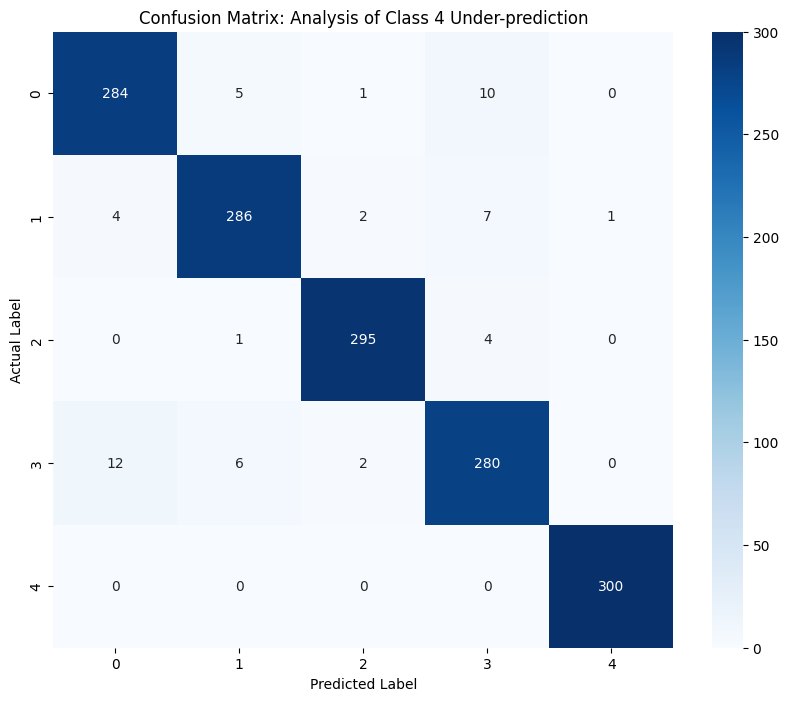

In [71]:
cm_df, cm = plot_confusion_matrix(val_labels, val_preds, class_names)

In [72]:
cm

array([[284,   5,   1,  10,   0],
       [  4, 286,   2,   7,   1],
       [  0,   1, 295,   4,   0],
       [ 12,   6,   2, 280,   0],
       [  0,   0,   0,   0, 300]])

In [230]:
def plot_confusion_prob_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    
    # --- 수정된 부분: 행(Actual) 기준 정규화 (전체 실제 데이터 중 맞춘 비율) ---
    cm_ratio = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    # fmt='.2f'로 수정하여 소수점 둘째 자리까지 표시
    sns.heatmap(cm_ratio, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    
    plt.title('Confusion Matrix (Normalized): Analysis of Class 4 Under-prediction')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 데이터프레임도 비율로 반환하고 싶다면 cm_ratio를 사용하세요
    cm_df = pd.DataFrame(
        cm_ratio, 
        index=[f"실제_{c}" for c in classes], 
        columns=[f"예측_{c}" for c in classes]
    )
    return cm_df, cm

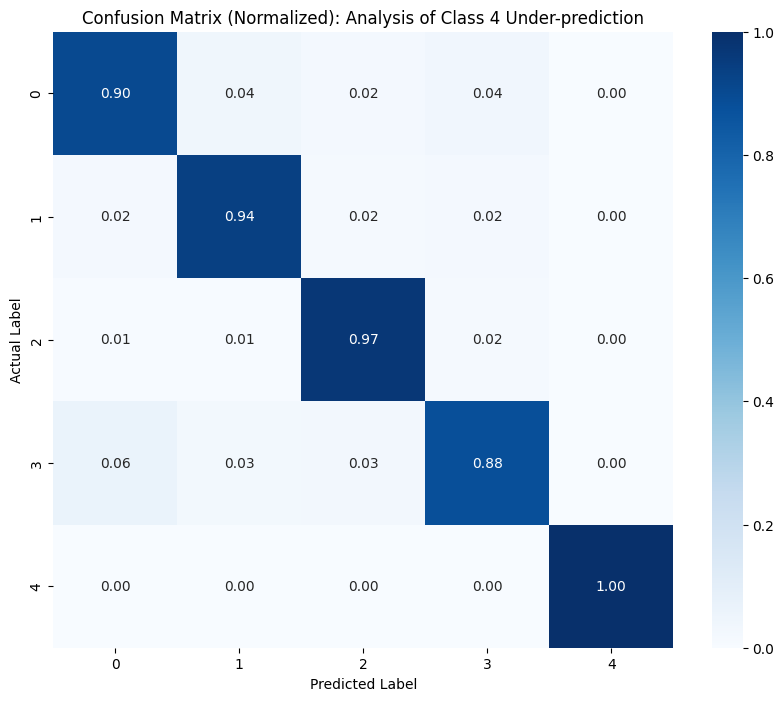

In [231]:
cm_df, cm = plot_confusion_prob_matrix(val_labels, val_preds, class_names)

#### 두 모델 앙상블 적용한 성능 사용할 경우

In [73]:
# 1. 각 모델의 predictions(Logits) 가져오기
roberta_logits = roberta_raw_preds.predictions
electra_logits = electra_raw_preds.predictions

In [74]:
roberta_lambda = 0.5

In [75]:
# 2. 소프트 보팅 (평균 내기)
# 산술 평균을 내도 되고, 단순히 더하기만 해도 argmax 결과는 같습니다.
# ensemble_logits = (roberta_logits + electra_logits) / 2
ensemble_logits = roberta_lambda* roberta_logits + (1-roberta_lambda)* electra_logits

# 3. 최종 클래스 결정
ensemble_preds = ensemble_logits.argmax(-1)

In [76]:
ensemble_counter = Counter(ensemble_preds)
ensemble_counter

Counter({np.int64(1): 104,
         np.int64(2): 103,
         np.int64(0): 102,
         np.int64(3): 101,
         np.int64(4): 90})

In [77]:
# 앙상블 결과 사용해서 저장할 때
ensemble_submit_df = pd.read_csv(TEST_DATA_PATH + 'submission.csv') # 이미 idx가 들어있는 파일
ensemble_submit_df.head()

ensemble_submit_df['class'] = ensemble_preds
ensemble_submit_df.head()

,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,4
4,t_004,3


In [80]:
# save_time = "04251626"

ensemble_submit_df.to_csv(f'submission_ensemble_{save_time}_{methods}_0427.csv', index=False)

In [81]:
f'submission_ensemble_{save_time}_{methods}_0427.csv'

'submission_ensemble_04251855_Cont4_temp05_mix05_if5_mask_bv_0427.csv'

In [82]:
roberta_lambda = 0.3

In [83]:
# 2. 소프트 보팅 (평균 내기)
# 산술 평균을 내도 되고, 단순히 더하기만 해도 argmax 결과는 같습니다.
# ensemble_logits = (roberta_logits + electra_logits) / 2
partial_ensemble_logits = roberta_lambda* roberta_logits + (1-roberta_lambda)* electra_logits

# 3. 최종 클래스 결정
partial_ensemble_preds = partial_ensemble_logits.argmax(-1)

In [84]:
partial_ensemble_counter = Counter(partial_ensemble_preds)
partial_ensemble_counter

Counter({np.int64(4): 114,
         np.int64(0): 107,
         np.int64(2): 99,
         np.int64(1): 98,
         np.int64(3): 82})

In [85]:
# 앙상블 결과 사용해서 저장할 때
partial_ensemble_submit_df = pd.read_csv(TEST_DATA_PATH + 'submission.csv') # 이미 idx가 들어있는 파일
partial_ensemble_submit_df.head()

partial_ensemble_submit_df['class'] = ensemble_preds
partial_ensemble_submit_df.head()

,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,4
4,t_004,3


In [86]:
# save_time = "04251626"

partial_ensemble_submit_df.to_csv(f'submission_ensemble_{save_time}_{methods}_roberta{roberta_lambda}.csv', index=False)

In [87]:
f'submission_ensemble_{save_time}_{methods}_roberta{roberta_lambda}.csv'

'submission_ensemble_04251855_Cont4_temp05_mix05_if5_mask_bv_roberta0.3.csv'

In [88]:
import torch
import torch.nn.functional as F

def power_mean_ensemble(logits_roberta, logits_kcelectra, weight_roberta, p=2.0):
    # 1. Numpy 배열을 Torch Tensor로 변환 (AttributeError 방지)
    # 만약 이미 Tensor라면 그대로 유지됩니다.
    tens_ro = torch.as_tensor(logits_roberta, dtype=torch.float32)
    tens_kc = torch.as_tensor(logits_kcelectra, dtype=torch.float32)
    
    # 2. 각 모델의 출력을 확률(0~1)로 변환
    prob_roberta = F.softmax(tens_ro, dim=-1)
    prob_kcelectra = F.softmax(tens_kc, dim=-1)
    
    # 3. 가중치 설정
    w_ro = weight_roberta
    w_kc = 1.0 - weight_roberta
    
    # 4. Power Mean 계산 (확신도 증폭)
    # p가 2 이상이면 '목소리 큰(확률 높은)' 모델의 의견이 지배적이 됩니다.
    combined_prob = (w_ro * (prob_roberta ** p) + w_kc * (prob_kcelectra ** p))
    
    # 5. 최종 예측값 반환 (다시 Numpy로 변환)
    preds = torch.argmax(combined_prob, dim=-1).numpy()
    return preds
    
    return preds

In [92]:
weight_roberta = 0.47

In [93]:
power_preds = power_mean_ensemble(roberta_logits, electra_logits, weight_roberta)

In [94]:
power_counter = Counter(power_preds)
power_counter

Counter({np.int64(0): 105,
         np.int64(1): 102,
         np.int64(2): 101,
         np.int64(4): 96,
         np.int64(3): 96})

In [95]:
# 앙상블 결과 사용해서 저장할 때
power_ensemble_submit_df = pd.read_csv(TEST_DATA_PATH + 'submission.csv') # 이미 idx가 들어있는 파일
power_ensemble_submit_df.head()

power_ensemble_submit_df['class'] = power_preds
power_ensemble_submit_df.head()

,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,4
4,t_004,3


In [96]:
power_ensemble_submit_df.to_csv(f'submission_ensemble_{save_time}_{methods}_power{weight_roberta}_0427.csv', index=False)

In [97]:
f'submission_ensemble_{save_time}_{methods}_power{weight_roberta}.csv'

'submission_ensemble_04251855_Cont4_temp05_mix05_if5_mask_bv_power0.47.csv'

logit 조정 시

In [76]:
ensemble_logits = (roberta_logits + electra_logits) / 2

# 이 수치를 5.0, 8.0, 10.0 식으로 조절하면서 4번이 100개 근처가 되는 지점을 찾으세요.
# 아마 10.0 ~ 20.0 사이에서 결정될 것입니다.
ensemble_logits[:, 4] += 9.

ensemble_preds = ensemble_logits.argmax(-1)

In [77]:
ensemble_counter = Counter(ensemble_preds)
ensemble_counter

Counter({np.int64(4): 500})

In [111]:
ensemble_submit_df = pd.read_csv(TEST_DATA_PATH + 'submission.csv') # 이미 idx가 들어있는 파일
ensemble_submit_df.head()

ensemble_submit_df['class'] = ensemble_preds
ensemble_submit_df.head()

,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,4
4,t_004,4


In [113]:
save_time = "04241744"

ensemble_submit_df.to_csv(f'submission_ensemble_{save_time}_{methods}_manual.csv', index=False)

In [154]:
ensemble_counter = Counter(ensemble_preds)
ensemble_counter

Counter({np.int64(3): 114,
         np.int64(4): 101,
         np.int64(1): 100,
         np.int64(2): 100,
         np.int64(0): 85})

In [ ]:
Counter({np.int64(3): 136,
         np.int64(1): 111,
         np.int64(2): 110,
         np.int64(0): 103,
         np.int64(4): 40})

In [82]:
a_label = [i // 100 for i in range(500)]
a_label = np.array(a_label)
len(a_label)
a_pred = [i // 100 for i in range(400)]
a_pred += [0]*50
a_pred += [1]*50
# a_pred += [2]*2
# a_pred += [3]*3
a_pred = np.array(a_pred)
len(a_pred)

500

In [83]:
f1_score(a_label, a_pred, average='macro')

0.72